In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [3]:
# Load the Excel file
file_path = "C://Users//win11//Desktop//Socbiz//Trilytcis 25//data//LTF Challenge data with dictionary.xlsx"
df = pd.read_excel("C://Users//win11//Desktop//Socbiz//Trilytcis 25//data//LTF Challenge data with dictionary.xlsx", sheet_name="TrainData")  # Adjust sheet_name if needed 


In [37]:
# Step 0: Clean and normalize string values
df["Ownership"] = df["Ownership"].str.strip().str.lower()
df["Address type"] = df["Address type"].str.strip().str.lower()

# Step 1: Drop 'Location' column if it exists
if "Location" in df.columns:
    df.drop(columns=["Location"], inplace=True)

# Step 2: Create binary flags for presence
df["Ownership_present"] = df["Ownership"].notna().astype(int)
df["Address_type_present"] = df["Address type"].notna().astype(int)

# Step 3: Fill missing values with 'nomads'
df["Ownership"] = df["Ownership"].fillna("nomads")
df["Address type"] = df["Address type"].fillna("nomads")

# Step 4: Map custom encodings

ownership_map = {
    "nomads": 0,
    "rented": 1,
    "parental": 2,
    "owned": 3
}

address_type_map = {
    "nomads": 0,
    "current address": 1,
    "permanent address": 2,
    "both addresses": 3
}

df["Ownership_encoded"] = df["Ownership"].map(ownership_map)
df["Address_type_encoded"] = df["Address type"].map(address_type_map)


In [38]:

df["Address_type_encoded"].isnull().sum()*100/len(df)

np.float64(0.0)

In [4]:
print("Shape of data:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())
print("\nSample records:\n", df.head())
print("\nSummary statistics:\n", df.describe())


Shape of data: (47970, 108)

Data types:
 float64    63
object     37
int64       8
Name: count, dtype: int64

Sample records:
            FarmerID           State   REGION SEX        CITY  Zipcode  \
0  1002818465057450  MADHYA PRADESH  CENTRAL   M      BARELI   464668   
1  1012300674433870           BIHAR     EAST   M      BANDRA   848125   
2  1013472263587380  MADHYA PRADESH  CENTRAL   M  MALHARGARH   458556   
3  1019525480704050     MAHARASHTRA     WEST   M     RENAPUR   413527   
4  1021915867444260  MADHYA PRADESH  CENTRAL   F      KHURAI   470117   

      DISTRICT   VILLAGE MARITAL_STATUS Address type  ...  \
0       RAISEN     Seoni              M       nomads  ...   
1  MUZAFFARPUR   Namapur              M       nomads  ...   
2     MANDSAUR   Billaud              M       nomads  ...   
3        LATUR   Renapur              M       nomads  ...   
4        SAGAR  Singhpur              M       nomads  ...   

   Village score based on socio-economic parameters (Non normalise

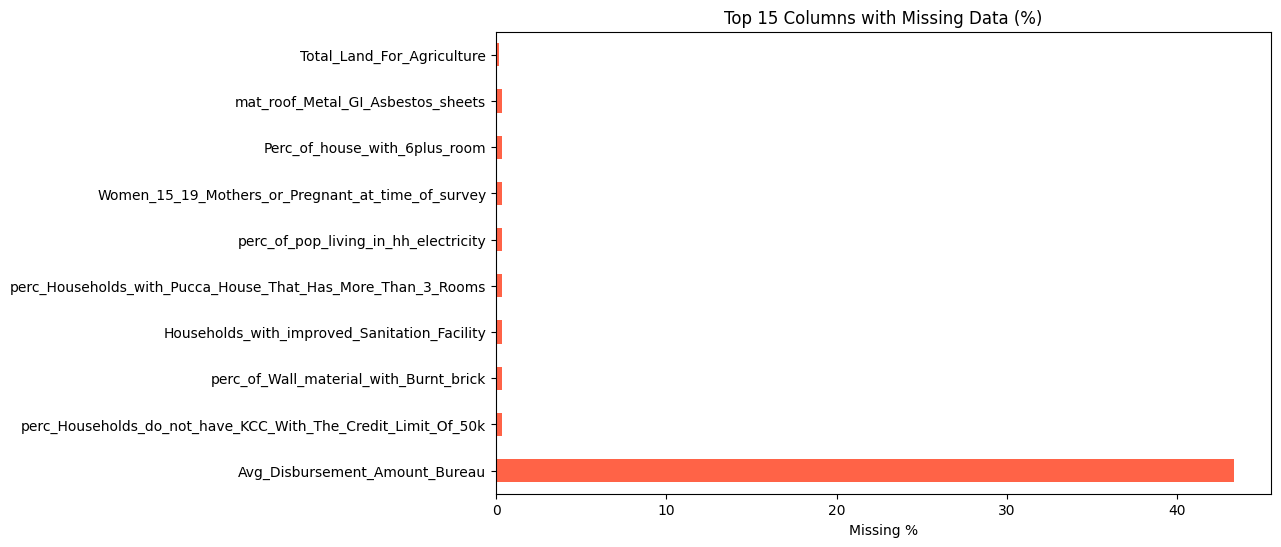

In [39]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
missing.to_frame("Missing %").style.background_gradient(cmap='Reds')

plt.figure(figsize=(10, 6))
missing[:15].plot(kind='barh', color='tomato')
plt.title("Top 15 Columns with Missing Data (%)")
plt.xlabel("Missing %")
plt.show()


count    4.797000e+04
mean     1.222255e+06
std      2.073935e+06
min      2.900000e+04
25%      7.200000e+05
50%      9.500000e+05
75%      1.295000e+06
max      8.000000e+07
Name: Target_Variable/Total Income, dtype: float64


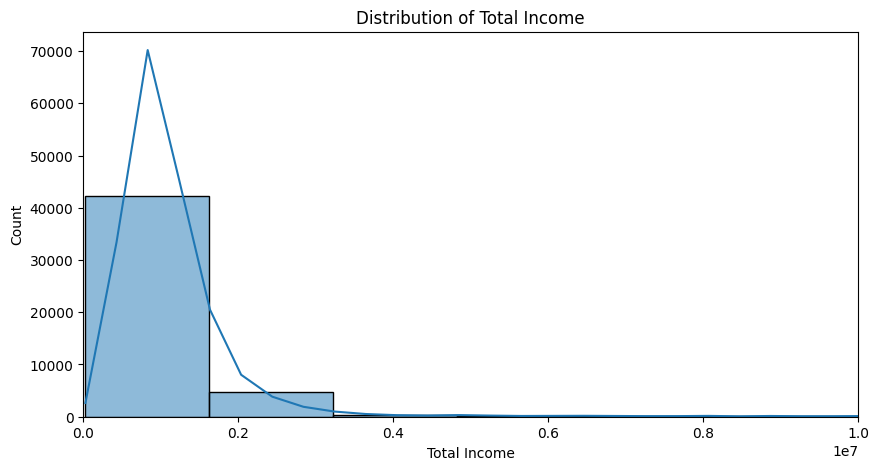

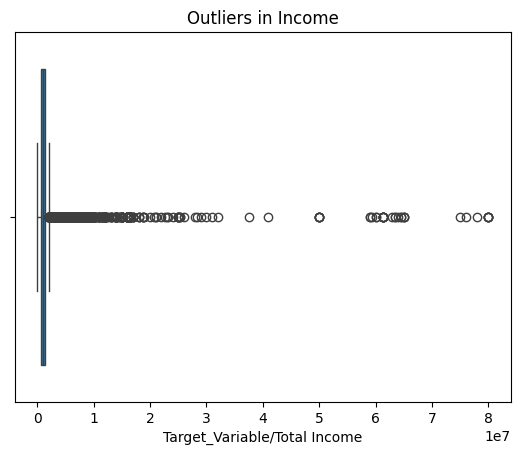

In [16]:
target = 'Target_Variable/Total Income'
print(df[target].describe())

plt.figure(figsize=(10,5))
sns.histplot(df[target], kde=True, bins=50)
plt.title("Distribution of Total Income")
plt.xlabel("Total Income")
plt.xlim(0, 10000000)  # Adjust as needed
plt.show()

# Boxplot to detect outliers
sns.boxplot(x=df[target])
plt.title("Outliers in Income")
plt.show()



--- Ownership ---
Ownership
owned       29462
nomads      17030
parental     1469
rented          9
Name: count, dtype: int64


C:\Users\win11\AppData\Local\Temp\ipykernel_20016\191114340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


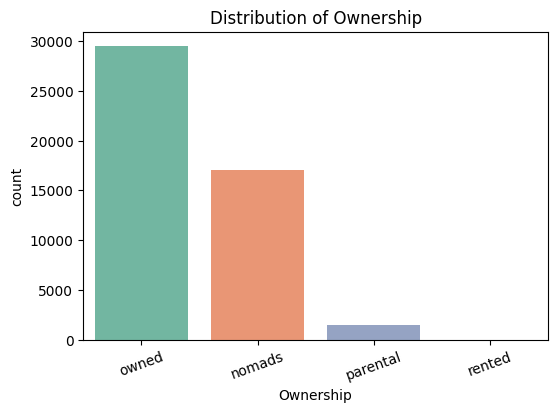


--- Ownership_encoded ---
Ownership_encoded
3    29462
0    17030
2     1469
1        9
Name: count, dtype: int64


C:\Users\win11\AppData\Local\Temp\ipykernel_20016\191114340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


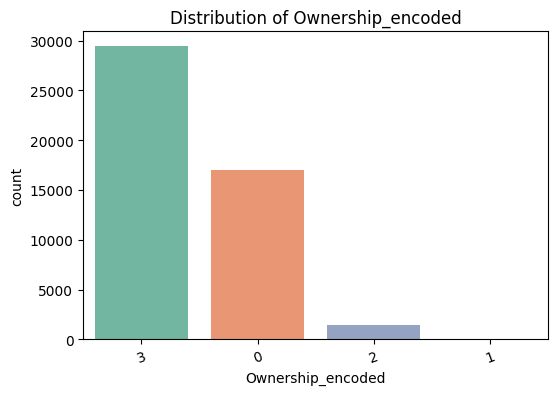


--- Address type ---
Address type
permanent address    26213
nomads               17030
current address       3964
both addresses         763
Name: count, dtype: int64


C:\Users\win11\AppData\Local\Temp\ipykernel_20016\191114340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


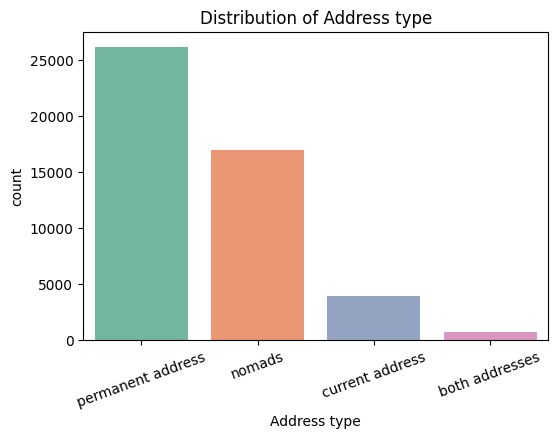


--- Address_type_encoded ---
Address_type_encoded
NaN    30940
0.0    17030
Name: count, dtype: int64


C:\Users\win11\AppData\Local\Temp\ipykernel_20016\191114340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


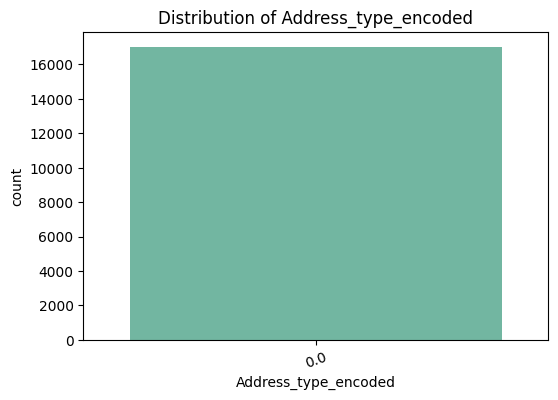


--- SEX ---
SEX
M    43295
F     4675
Name: count, dtype: int64


C:\Users\win11\AppData\Local\Temp\ipykernel_20016\191114340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


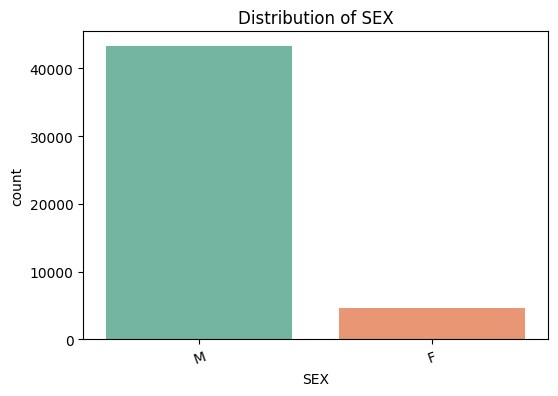


--- MARITAL_STATUS ---
MARITAL_STATUS
M     44168
S      3798
NK        4
Name: count, dtype: int64


C:\Users\win11\AppData\Local\Temp\ipykernel_20016\191114340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


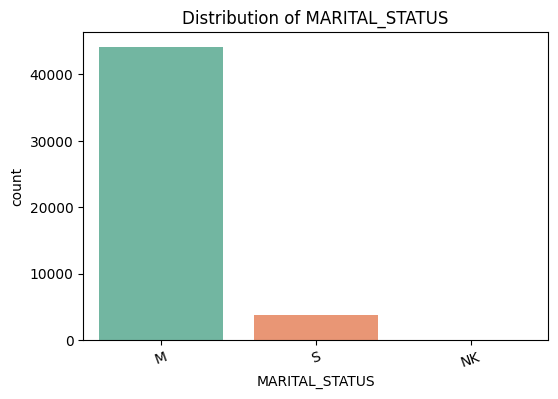

In [17]:
categorical = ["Ownership", "Ownership_encoded", "Address type", "Address_type_encoded", "SEX", "MARITAL_STATUS"]

for col in categorical:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))
    
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=20)
    plt.show()


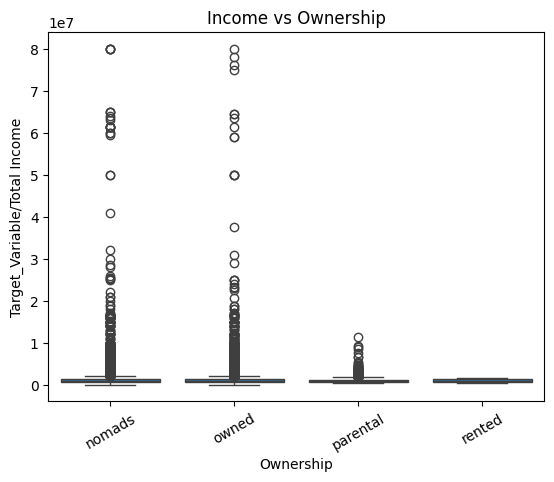

In [18]:
sns.boxplot(data=df, x="Ownership", y=target)
plt.title("Income vs Ownership")
plt.xticks(rotation=30)
plt.show()


Highest Median Income:

Owned and Nomads have similar median income—they appear slightly higher than parental and rented.

Extreme Outliers:

Both nomads and owned have several high-income outliers (above ₹2 Cr).

This suggests that a few individuals in these categories earn significantly more.

Lowest Median Income:

Rented land owners have the lowest income overall with minimal spread.

Parental land owners also show less variance than owned.

Wider Spread in Owned/Nomads:

There’s greater variability (income inequality) among owned and nomads.

This could suggest these groups include both rich and poor farmers, while rented and parental are more uniform.

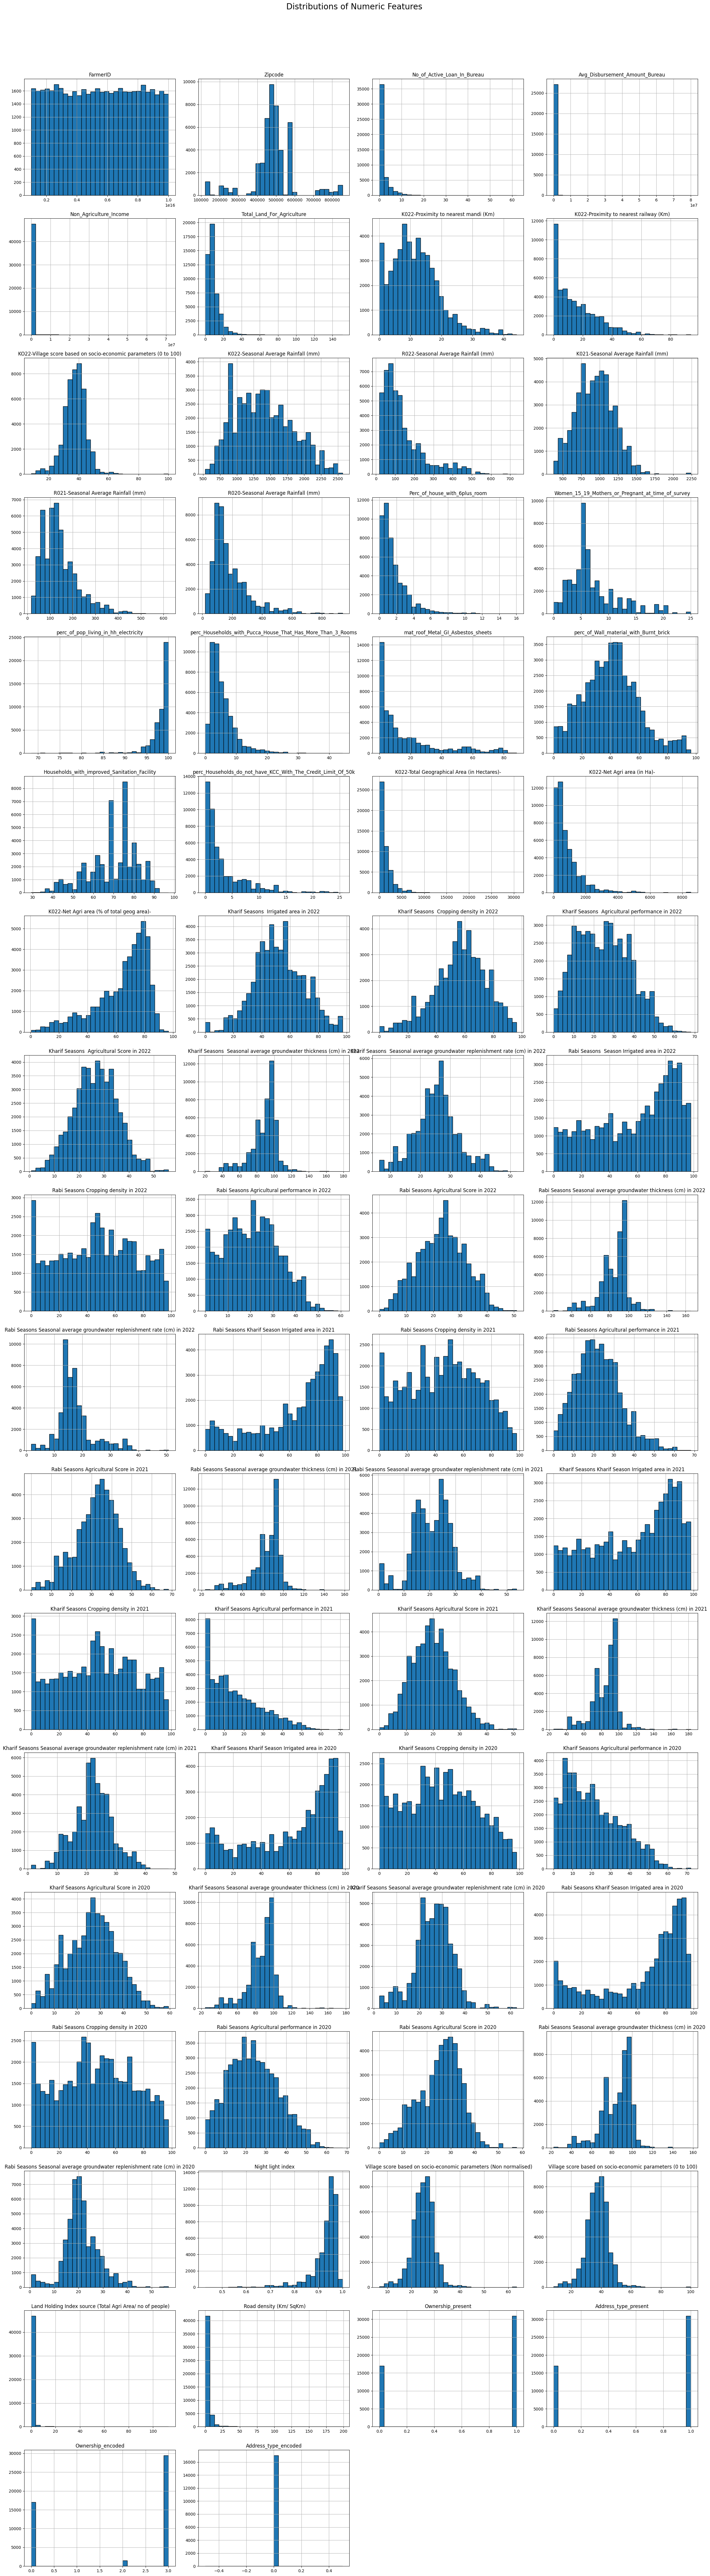

Avg_Disbursement_Amount_Bureau                                      63.265365
Non_Agriculture_Income                                              26.618204
 Land Holding Index source (Total Agri Area/ no of people)          13.917756
 Road density (Km/ SqKm)                                             6.490547
No_of_Active_Loan_In_Bureau                                          3.044518
                                                                      ...    
Rabi Seasons Seasonal average groundwater thickness (cm) in 2020    -1.011465
K022-Net Agri area (% of total geog area)-                          -1.093108
Rabi Seasons Seasonal average groundwater thickness (cm) in 2021    -1.236641
 Night light index                                                  -2.623091
perc_of_pop_living_in_hh_electricity                                -4.906528
Length: 70, dtype: float64

In [23]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['number']).columns.drop(target)

# Calculate optimal grid size
n_cols = 4  # You can change this based on your screen
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Round up

# Plot with layout
df[numeric_cols].hist(
    figsize=(6 * n_cols, 5 * n_rows),
    bins=30,
    edgecolor='black',
    layout=(n_rows, n_cols)
)

plt.suptitle("Distributions of Numeric Features", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()
df[numeric_cols].skew().sort_values(ascending=False)




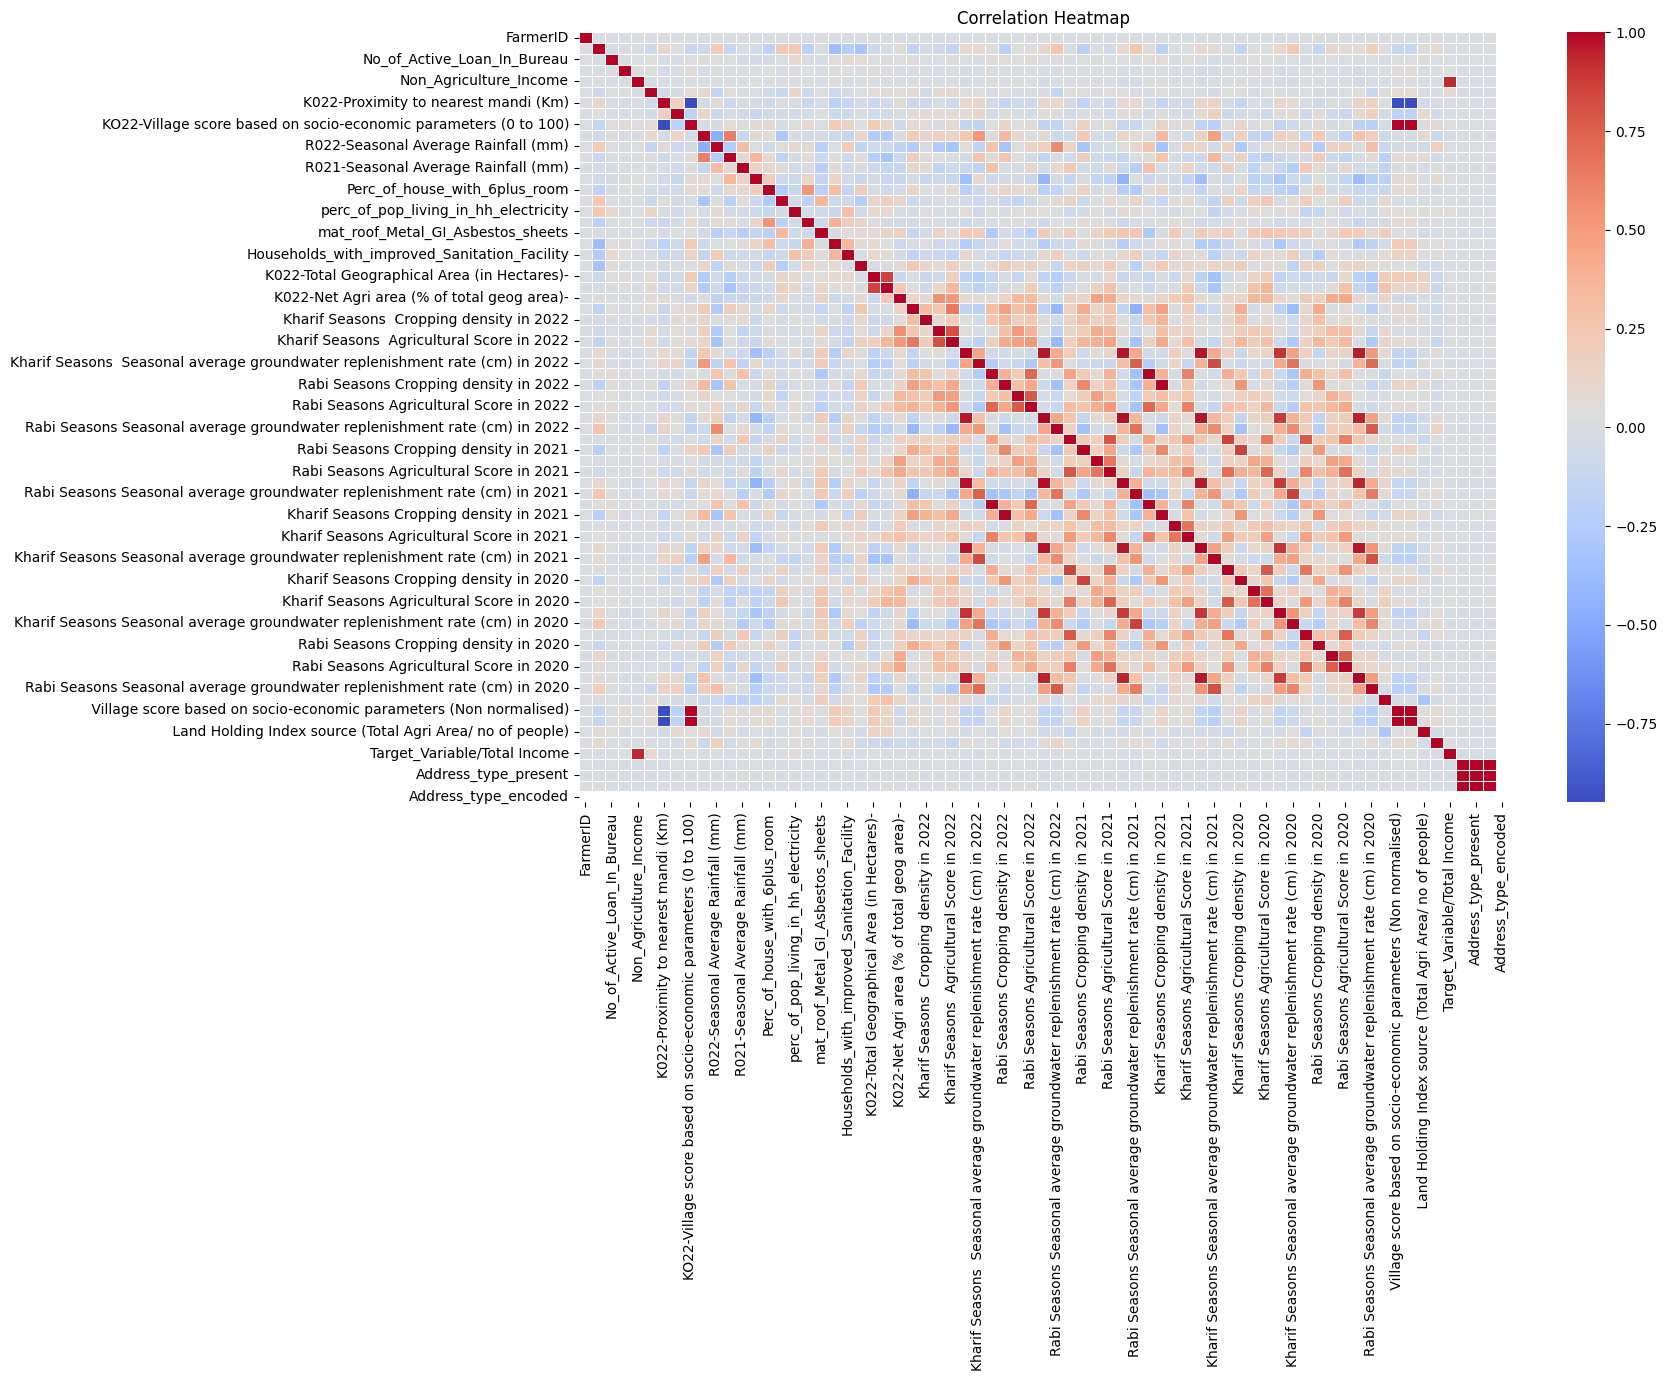

In [24]:
plt.figure(figsize=(15, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


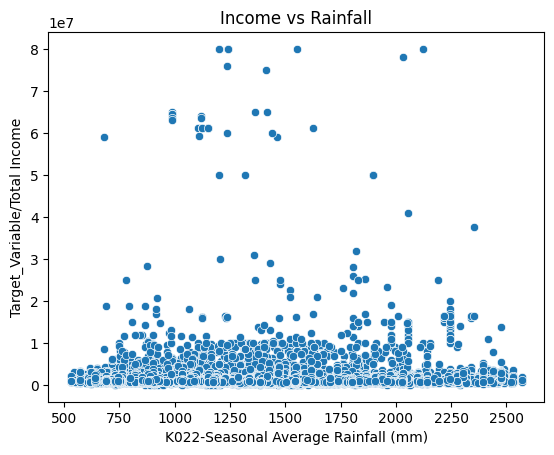

In [25]:
sns.scatterplot(x='K022-Seasonal Average Rainfall (mm)', y=target, data=df)
plt.title("Income vs Rainfall")
plt.show()


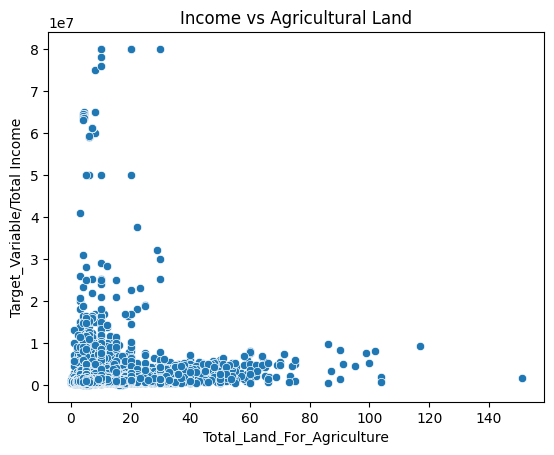

In [26]:
sns.scatterplot(x='Total_Land_For_Agriculture', y=target, data=df)
plt.title("Income vs Agricultural Land")
plt.show()


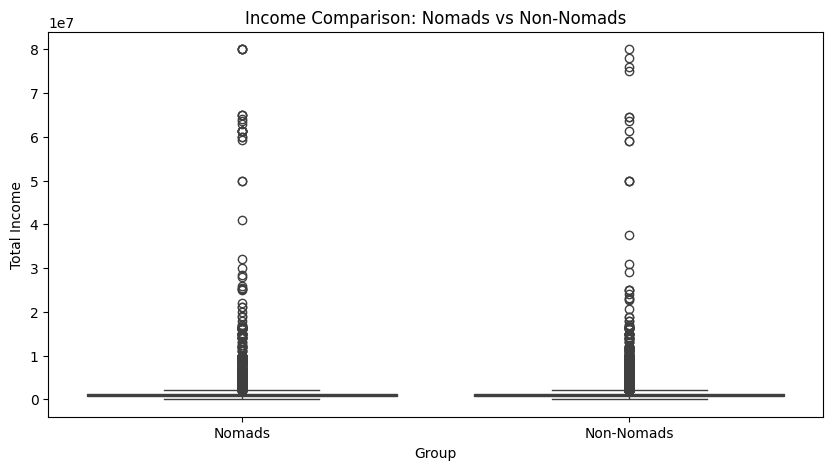

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x="Ownership_present", y='Target_Variable/Total Income', data=df)
plt.title("Income Comparison: Nomads vs Non-Nomads")
plt.xticks([0, 1], ['Nomads', 'Non-Nomads'])
plt.ylabel("Total Income")
plt.xlabel("Group")
plt.show()


In [28]:
grouped_stats = df.groupby("Ownership_present")["Target_Variable/Total Income"].agg(["count", "mean", "median", "std"])
grouped_stats.index = ["Nomads", "Non-Nomads"]
print(grouped_stats)


            count          mean    median           std
Nomads      17030  1.292361e+06  950000.0  2.612863e+06
Non-Nomads  30940  1.183668e+06  940000.0  1.704967e+06


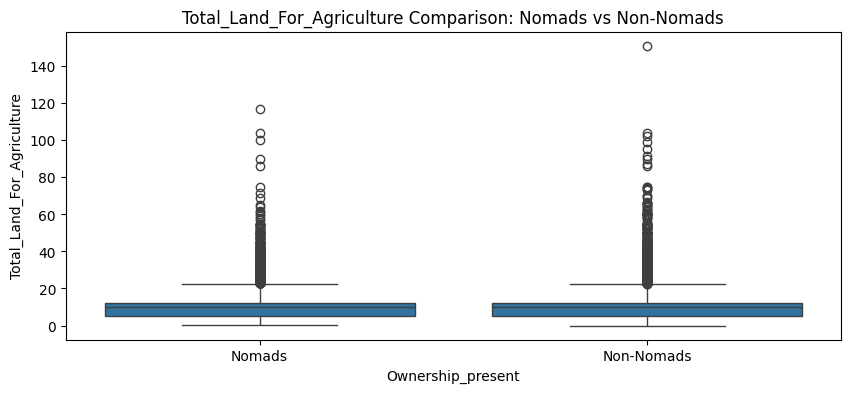

ValueError: Could not interpret value `Kharif_Agriculture_Index_Avg` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x400 with 0 Axes>

In [29]:
features_to_compare = ['Total_Land_For_Agriculture', 'Kharif_Agriculture_Index_Avg', 'Rabi_Agriculture_Index_Avg']

for col in features_to_compare:
    plt.figure(figsize=(10,4))
    sns.boxplot(x="Ownership_present", y=col, data=df)
    plt.xticks([0, 1], ['Nomads', 'Non-Nomads'])
    plt.title(f"{col} Comparison: Nomads vs Non-Nomads")
    plt.show()


In [4]:
from scipy.stats import skew

# Skewness of numeric columns
skewed_feats = df.select_dtypes(include='number').apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("Most skewed features:\n", skewed_feats.head(10))

# Log-transform target if needed
import numpy as np
df["log_income"] = np.log1p(df["Target_Variable/Total Income"])



Most skewed features:
 Avg_Disbursement_Amount_Bureau                                63.261874
Non_Agriculture_Income                                        26.617371
Target_Variable/Total Income                                  23.120872
 Land Holding Index source (Total Agri Area/ no of people)    13.917321
 Road density (Km/ SqKm)                                       6.490344
No_of_Active_Loan_In_Bureau                                    3.044423
K022-Total Geographical Area (in Hectares)-                    2.814992
K022-Net Agri area (in Ha)-                                    2.786026
Total_Land_For_Agriculture                                     2.711723
Perc_of_house_with_6plus_room                                  2.566849
dtype: float64


In [5]:
corrs = df.corr(numeric_only=True)["Target_Variable/Total Income"].sort_values(ascending=False)
print("Top positive correlators:\n", corrs.head(10))
print("\nTop negative correlators:\n", corrs.tail(10))


Top positive correlators:
 Target_Variable/Total Income                                          1.000000
Non_Agriculture_Income                                                0.934897
log_income                                                            0.619739
Total_Land_For_Agriculture                                            0.102707
perc_of_pop_living_in_hh_electricity                                  0.054801
Avg_Disbursement_Amount_Bureau                                        0.024691
Rabi Seasons  Season Irrigated area in 2022                           0.023521
Kharif Seasons Kharif Season Irrigated area in 2021                   0.023521
 Village score based on socio-economic parameters (Non normalised)    0.022628
KO22-Village score based on socio-economic parameters (0 to 100)      0.022628
Name: Target_Variable/Total Income, dtype: float64

Top negative correlators:
 Kharif Seasons Seasonal average groundwater thickness (cm) in 2021             -0.019887
Kharif Seasons 

In [6]:
cat_cols = ["Sex", "Marital_Status", "Address type", "Ownership", ""]
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=col, y="Target_Variable/Total Income", data=df)
    plt.title(f"Income distribution by {col}")
    plt.xticks(rotation=45)
    plt.show()



ValueError: Could not interpret value `Sex` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x400 with 0 Axes>

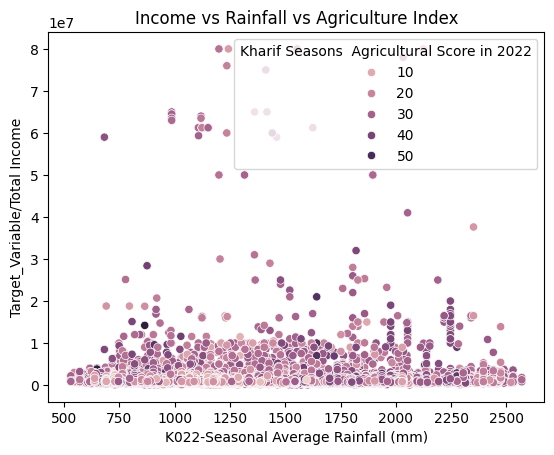

In [16]:
sns.scatterplot(data=df, x="K022-Seasonal Average Rainfall (mm)", y="Target_Variable/Total Income", hue="Kharif Seasons  Agricultural Score in 2022")
plt.title("Income vs Rainfall vs Agriculture Index")
plt.show()


In [8]:
missing_flags = df.isnull().astype(int)
for col in missing_flags.columns:
    df[f"{col}_missing_flag"] = missing_flags[col]

# Compare with income
missing_corr = df[[f"{col}_missing_flag" for col in missing_flags.columns]].corrwith(df["Target_Variable/Total Income"]).sort_values(ascending=False)
print("Missing flags with strongest correlation to income:\n", missing_corr.head(10))


C:\Users\win11\AppData\Local\Temp\ipykernel_22988\3922272918.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_missing_flag"] = missing_flags[col]
C:\Users\win11\AppData\Local\Temp\ipykernel_22988\3922272918.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_missing_flag"] = missing_flags[col]
C:\Users\win11\AppData\Local\Temp\ipykernel_22988\3922272918.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

Missing flags with strongest correlation to income:
 Location_missing_flag                                                       0.025079
Address type_missing_flag                                                   0.025079
Ownership_missing_flag                                                      0.025079
Women_15_19_Mothers_or_Pregnant_at_time_of_survey_missing_flag             -0.000933
Perc_of_house_with_6plus_room_missing_flag                                 -0.000933
mat_roof_Metal_GI_Asbestos_sheets_missing_flag                             -0.000933
perc_of_Wall_material_with_Burnt_brick_missing_flag                        -0.000933
perc_of_pop_living_in_hh_electricity_missing_flag                          -0.000933
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms_missing_flag   -0.000933
Households_with_improved_Sanitation_Facility_missing_flag                  -0.000933
dtype: float64


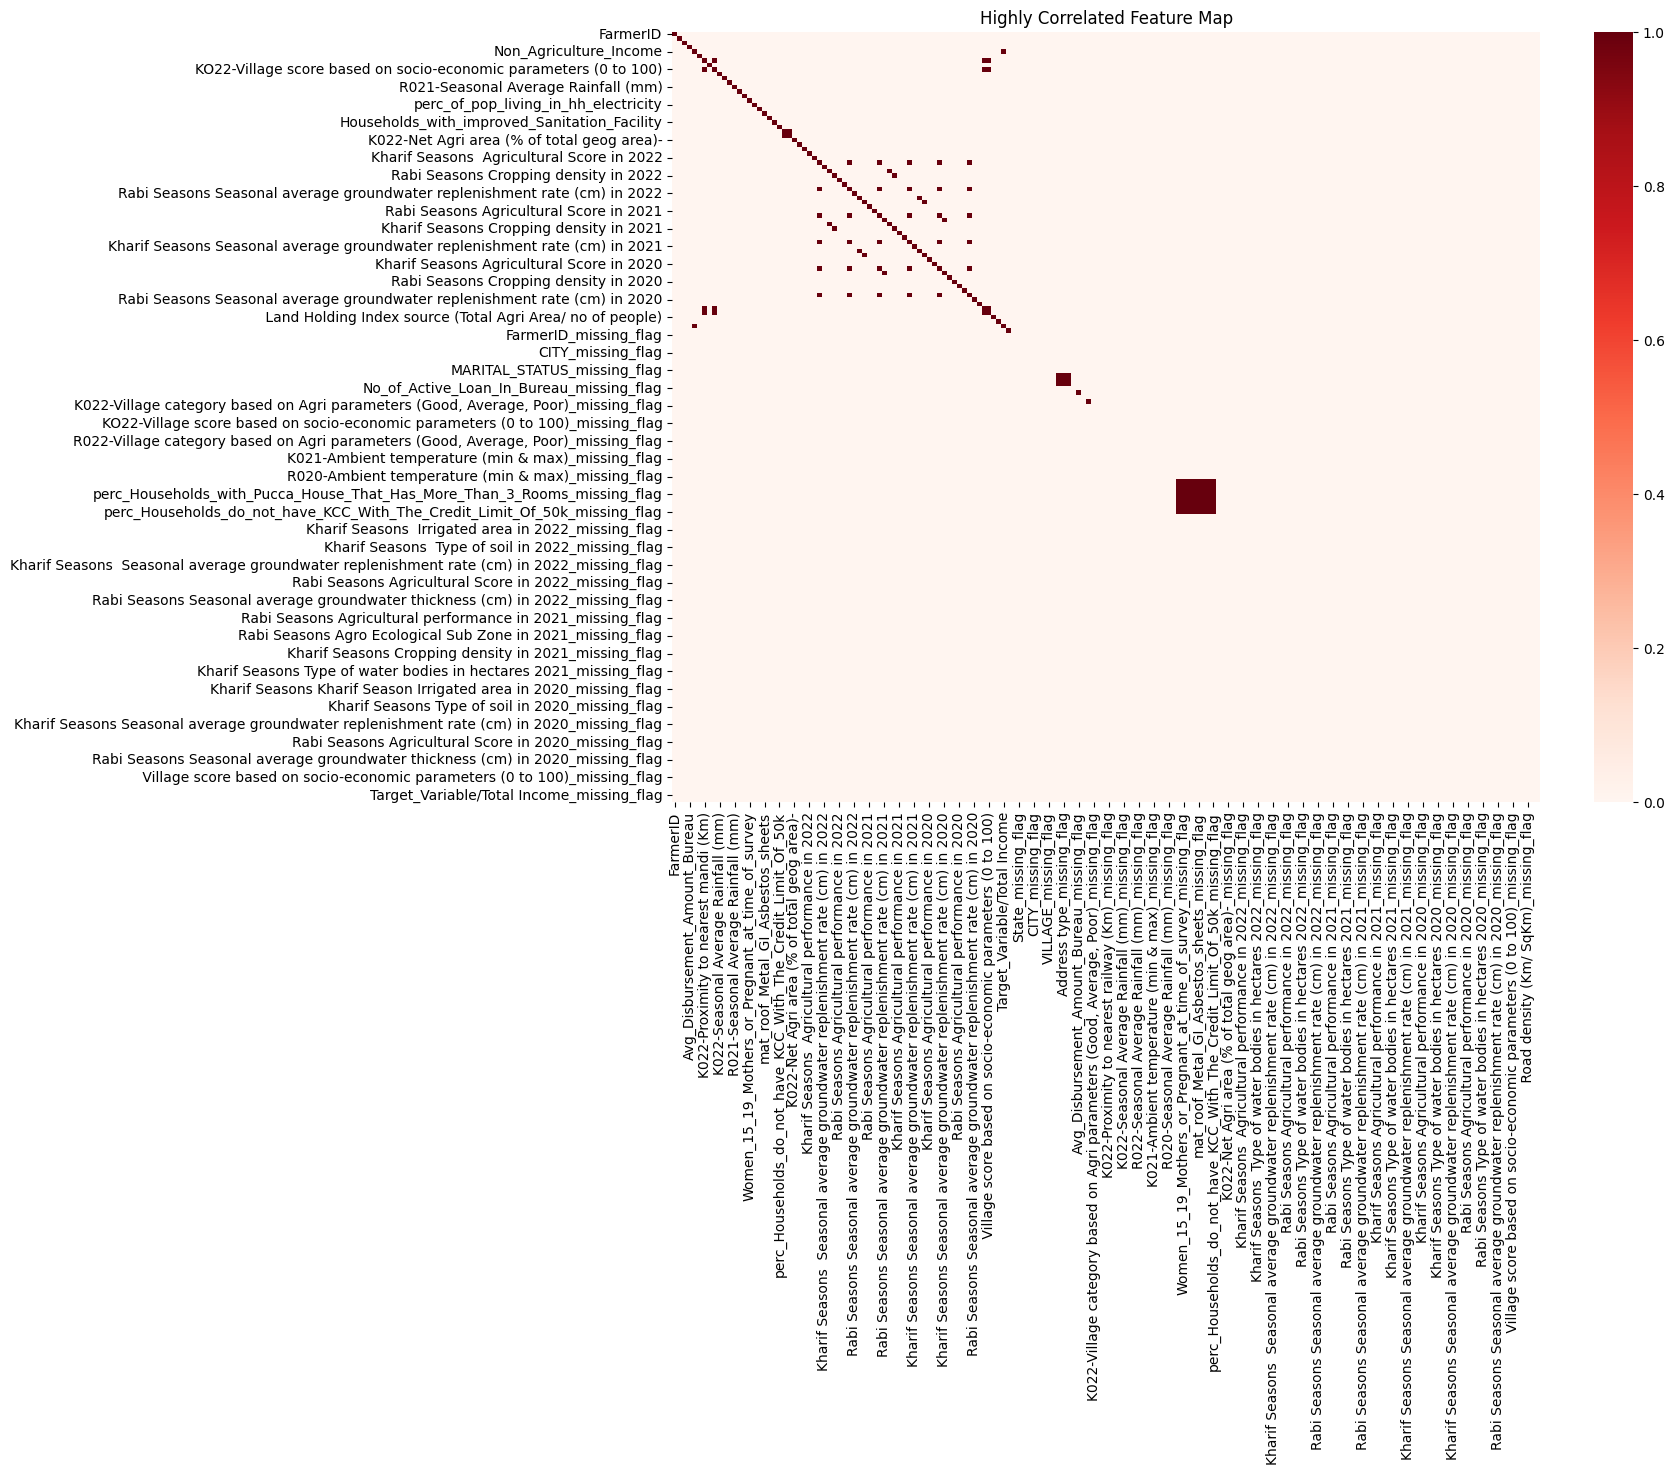

In [9]:
import seaborn as sns
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True).abs() > 0.85, cmap="Reds")
plt.title("Highly Correlated Feature Map")
plt.show()


C:\Users\win11\AppData\Local\Temp\ipykernel_22988\4139034415.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_outlier"] = outliers == -1


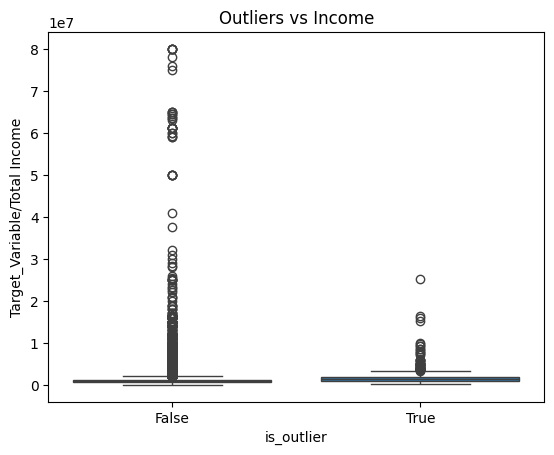

In [10]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(df.select_dtypes(include='number').fillna(0))
df["is_outlier"] = outliers == -1

# Visualize impact
sns.boxplot(x="is_outlier", y="Target_Variable/Total Income", data=df)
plt.title("Outliers vs Income")
plt.show()


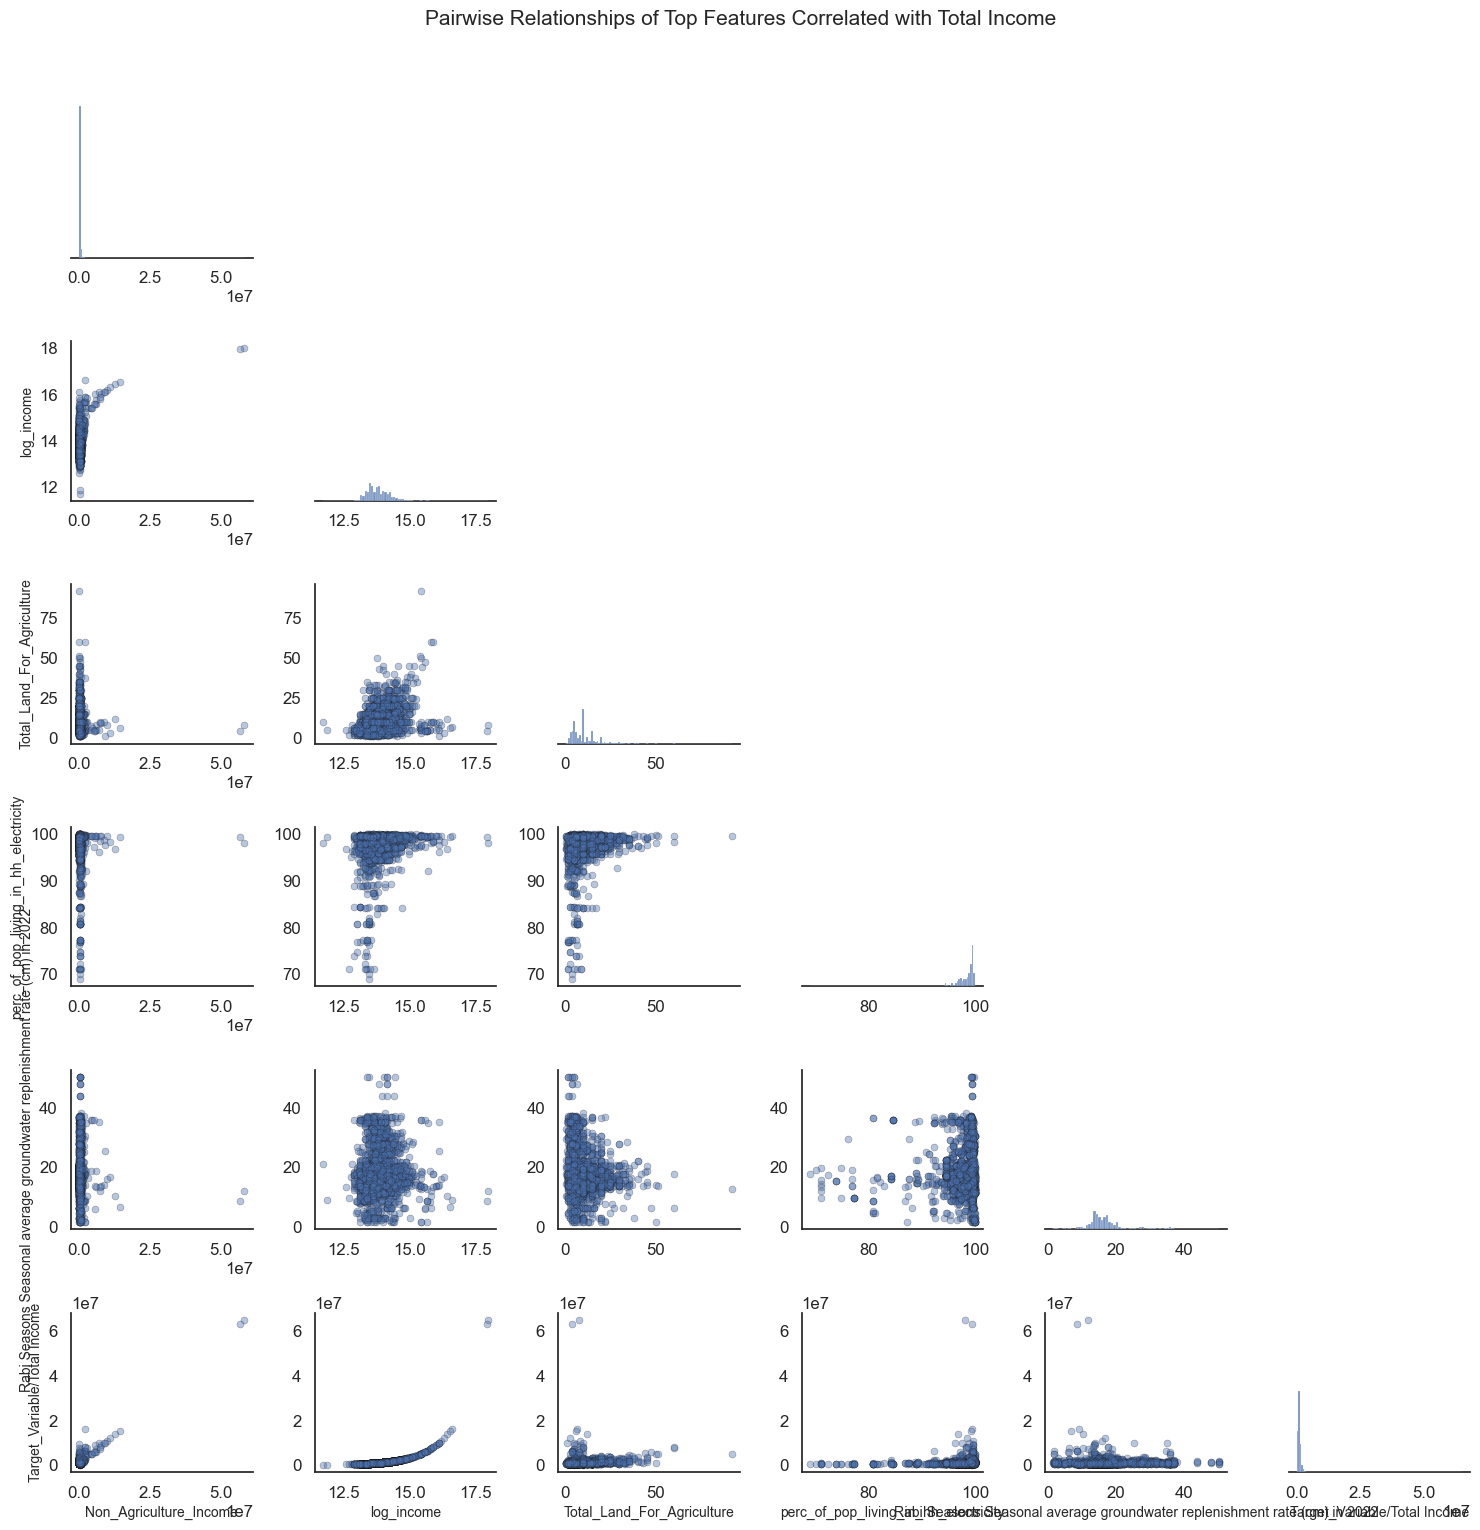

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Subset and Sample (for visual clarity)
target = "Target_Variable/Total Income"
sample_df = df.sample(n=3000, random_state=42)  # sample for readability

# Step 2: Select top features (can be customized)
features = [
    "Non_Agriculture_Income",
    "log_income",
    "Total_Land_For_Agriculture",
    "perc_of_pop_living_in_hh_electricity",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022",
    target
]

# Step 3: Create clean and readable pairplot
sns.set(style="white", font_scale=1.1)
g = sns.pairplot(sample_df[features], corner=True, 
                 plot_kws={'alpha': 0.4, 's': 25, 'edgecolor': 'k'}, 
                 diag_kws={'fill': True}, 
                 height=2.5)

# Step 4: Improve axis formatting
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelbottom=True, labelleft=True)
        ax.set_xlabel(ax.get_xlabel(), fontsize=10)
        ax.set_ylabel(ax.get_ylabel(), fontsize=10)

# Step 5: Title and Layout
plt.suptitle("Pairwise Relationships of Top Features Correlated with Total Income", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


C:\Users\win11\AppData\Local\Temp\ipykernel_22988\2960192677.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["income_bins"] = pd.qcut(df["Target_Variable/Total Income"], q=4, labels=["Low", "Medium", "High", "Very High"])


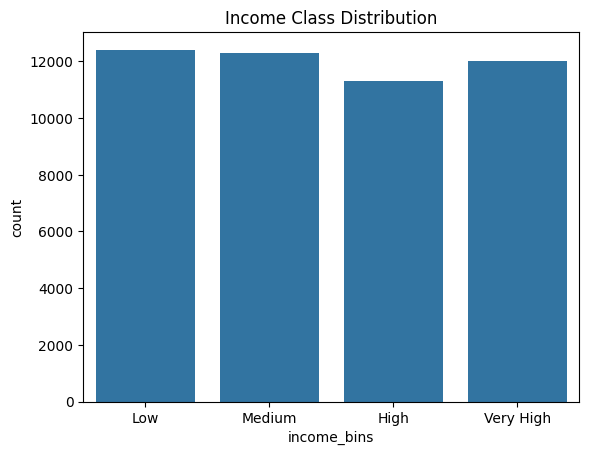

In [12]:
df["income_bins"] = pd.qcut(df["Target_Variable/Total Income"], q=4, labels=["Low", "Medium", "High", "Very High"])

sns.countplot(data=df, x="income_bins", order=["Low", "Medium", "High", "Very High"])
plt.title("Income Class Distribution")
plt.show()


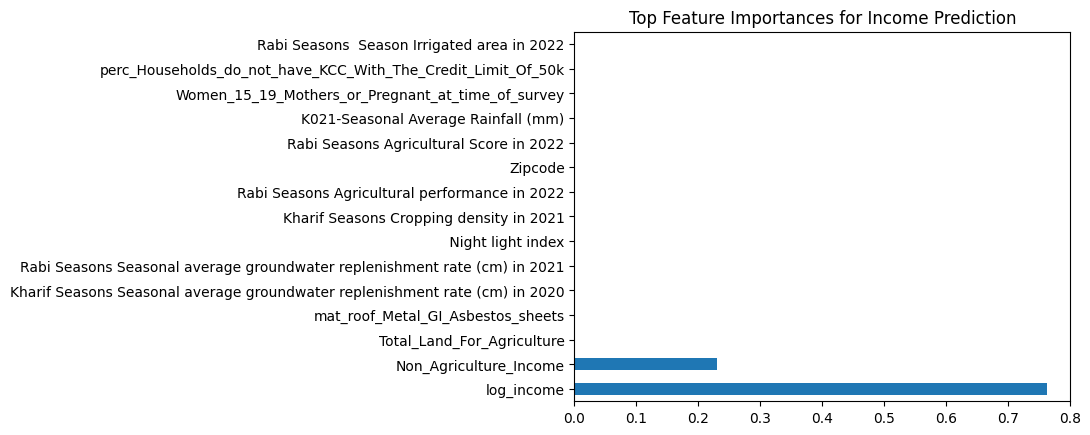

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include='number').drop(columns=["Target_Variable/Total Income"])
y = df["Target_Variable/Total Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

feat_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
feat_importance.plot(kind='barh')
plt.title("Top Feature Importances for Income Prediction")
plt.show()
